# **Importing the Dependencies**

In [1]:
%pip install pandas sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sqlalchemy import create_engine

In [3]:
# Update credentials
username = "postgres"
password = "Admin"
host = "localhost"
port = "5432"
database = "fraud_db"

# Create engine
engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("Connected to PostgreSQL")

Connected to PostgreSQL


In [4]:
import pandas as pd
query = "SELECT * FROM creditcard"

df = pd.read_sql(query, engine)

print("Data Loaded Successfully")
print("Shape:", df.shape)

df.head()

Data Loaded Successfully
Shape: (284807, 31)


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Importing the libraries

import numpy as np
import time

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy import stats

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import sklearn
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


# ignore warnings
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import pickle

sns.set(style="whitegrid")


# **Explotery Data Analysis**

In [6]:
# Load the Data Set
#df = pd.read_csv(r'E:\INFYNTREK_DA\Transactional Fraud Detection\data\creditcard.csv')
#df

In [7]:
# Checking the shape
df.shape

(284807, 31)

In [8]:
# Checking the data types and Null / Non-Null distributions
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    284807 non-null  float64
 1   v1      284807 non-null  float64
 2   v2      284807 non-null  float64
 3   v3      284807 non-null  float64
 4   v4      284807 non-null  float64
 5   v5      284807 non-null  float64
 6   v6      284807 non-null  float64
 7   v7      284807 non-null  float64
 8   v8      284807 non-null  float64
 9   v9      284807 non-null  float64
 10  v10     284807 non-null  float64
 11  v11     284807 non-null  float64
 12  v12     284807 non-null  float64
 13  v13     284807 non-null  float64
 14  v14     284807 non-null  float64
 15  v15     284807 non-null  float64
 16  v16     284807 non-null  float64
 17  v17     284807 non-null  float64
 18  v18     284807 non-null  float64
 19  v19     284807 non-null  float64
 20  v20     284807 non-null  float64
 21  v21     28

In [9]:
df = df.drop_duplicates()

In [10]:
# Checking the distribution of Numerical Values in the data set
df.describe()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [11]:
# Checking the class distribution fo the target variable
df['class'].value_counts()

class
0    283253
1       473
Name: count, dtype: int64

In [12]:
# Checking the class distribution fo the Target Variable in precentage
((df.groupby('class')['class'].count()/df['class'].count()) * 100)

class
0    99.83329
1     0.16671
Name: class, dtype: float64

<Axes: ylabel='class'>

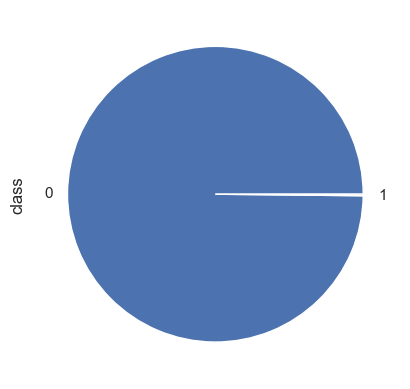

In [13]:
# Ploting in pie chart
Target_variable = ((df.groupby('class')['class'].count()/df['class'].count()) * 100)
Target_variable.plot.pie()

In [14]:
# Checking the % distribution of normal vs Fraud
classes = df['class'].value_counts()
normal_shear = classes[0]/df['class'].count() * 100
fraud_shear = classes[1]/df['class'].count() * 100

print(normal_shear)
print(fraud_shear)


99.83328986416473
0.1667101358352777


In [15]:
# Checking the null values in the data set
df.isnull().sum()

time      0
v1        0
v2        0
v3        0
v4        0
v5        0
v6        0
v7        0
v8        0
v9        0
v10       0
v11       0
v12       0
v13       0
v14       0
v15       0
v16       0
v17       0
v18       0
v19       0
v20       0
v21       0
v22       0
v23       0
v24       0
v25       0
v26       0
v27       0
v28       0
amount    0
class     0
dtype: int64

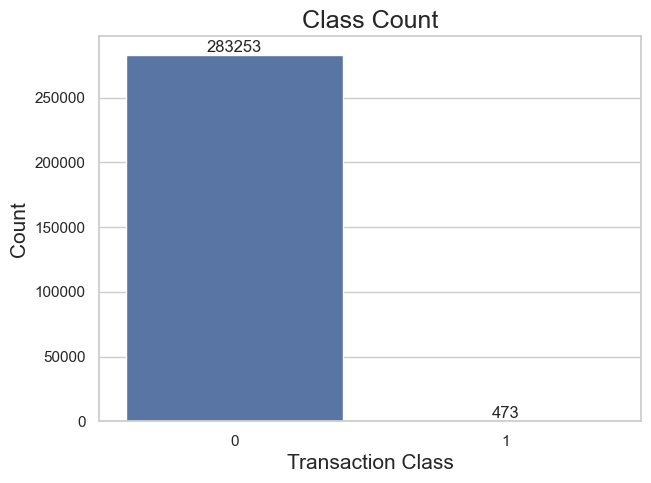

In [16]:
# Create Bar plot for the number and percentage of Legitimate and Fradulent transections
class_counts = df['class'].value_counts()

plt.figure(figsize=(7,5))
#sns.countplot(x='Class', data=df)
ax = sns.barplot(x=class_counts.index, y=class_counts.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Class Count", fontsize=18)
plt.xlabel("Transaction Class", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.show()

* 0 means **Legitimate** Transections and 1 means **Fraud** Transections
* The class distribution shows that the dataset is highly imbalanced, where non-fraud transactions dominate the dataset while fraud cases represent only a small fraction.
* This imbalance creates challenges for machine learning models, as they may become biased toward the majority class. Therefore, specialized techniques such as resampling and appropriate evaluation metrics are required to effectively detect fraudulent transactions.

In [17]:
#Cheking the correlation
corr = df.corr()
corr

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
v1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
v2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
v3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
v4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
v5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
v6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
v7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
v8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
v9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


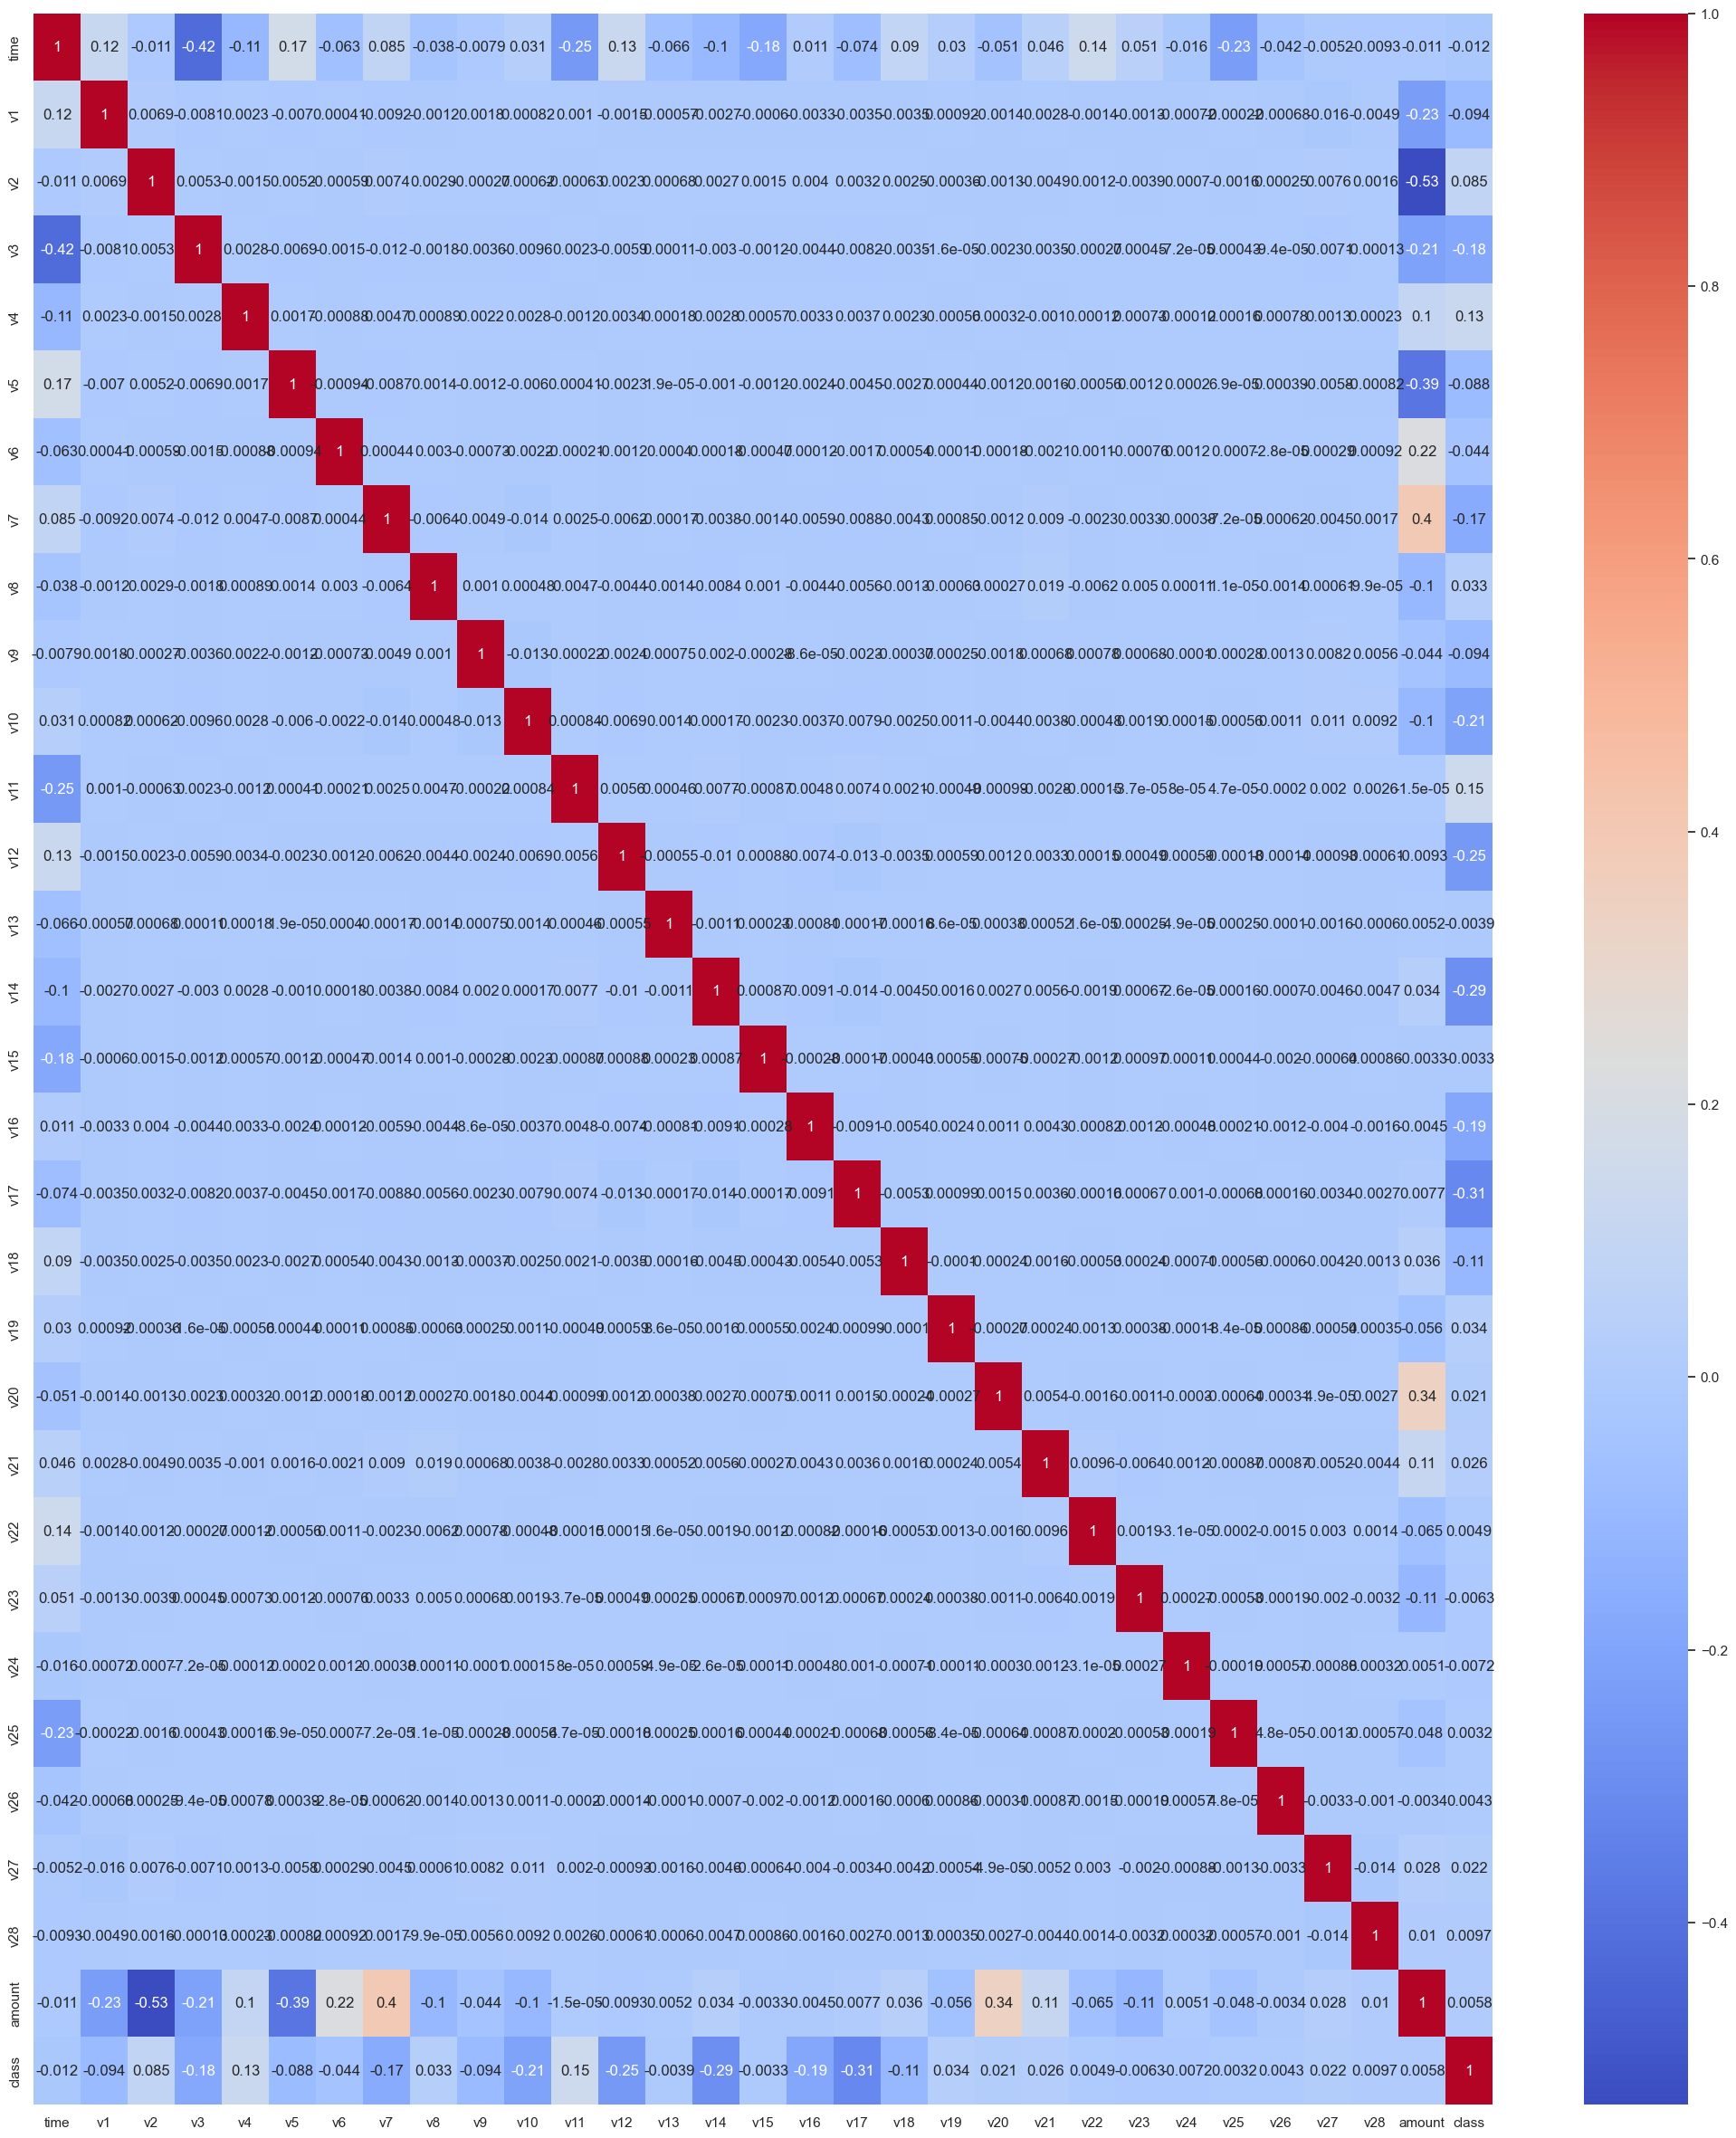

In [18]:
# Checking the correlation in heatmap
plt.figure(figsize = (26,30))
sns.heatmap(corr, cmap = 'coolwarm', annot = True)
plt.show()

* The correlation heatmap shows that most features have very low correlation with each other due to PCA transformation. 
* The fraud class also has weak correlations with most variables, indicating that fraudulent patterns are complex and not easily separable using simple linear relationships. 
* This suggests the need for advanced machine learning models to effectively detect fraudulent transactions.

In [19]:
delta_time = pd.to_timedelta(df['time'], unit = 's')
delta_time

0        0 days 00:00:00
1        0 days 00:00:00
2        0 days 00:00:01
3        0 days 00:00:01
4        0 days 00:00:02
               ...      
284802   1 days 23:59:46
284803   1 days 23:59:47
284804   1 days 23:59:48
284805   1 days 23:59:48
284806   1 days 23:59:52
Name: time, Length: 283726, dtype: timedelta64[ns]

* The DeltaTime feature represents the **Time Difference between Consecutive Transactions**. This feature helps capture transaction frequency patterns, which can be useful for identifying fraudulent behavior, as fraudsters often perform multiple transactions within a short period of time.

In [20]:
# Create derived columns minutes, hours, days
df['time_hours'] = (delta_time.dt.components.hours).astype(int)

df['Time_Days'] = (delta_time.dt.components.days).astype(int)
df['Time_Minutes'] = (delta_time.dt.components.minutes).astype(int)
df['time_hours']

0          0
1          0
2          0
3          0
4          0
          ..
284802    23
284803    23
284804    23
284805    23
284806    23
Name: time_hours, Length: 283726, dtype: int32

In [21]:
df

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v24,v25,v26,v27,v28,amount,class,time_hours,Time_Days,Time_Minutes
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23,1,59
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23,1,59
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23,1,59
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23,1,59


In [22]:
# Drop unnecessary column

df.drop(['Time_Minutes','Time_Days'], axis = 1, errors ='ignore',inplace = True)
df

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v22,v23,v24,v25,v26,v27,v28,amount,class,time_hours
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23


In [23]:
df.drop('time', axis = 1, inplace = True)

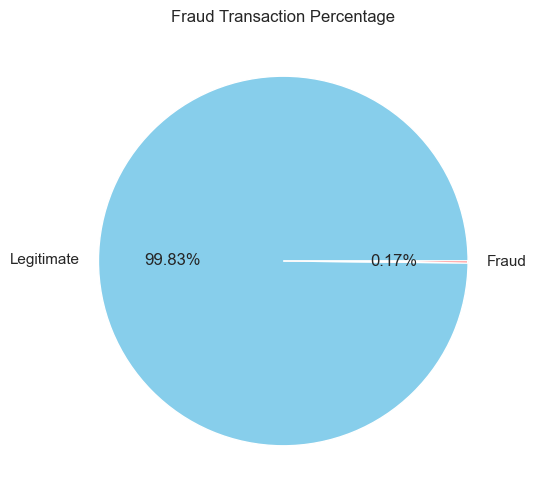

In [24]:
# Fraud Percentage Pie Chart

fraud_counts = df["class"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=["Legitimate","Fraud"],
    autopct="%1.2f%%",
    colors=["skyblue","red"]
)

plt.title("Fraud Transaction Percentage")

plt.show()

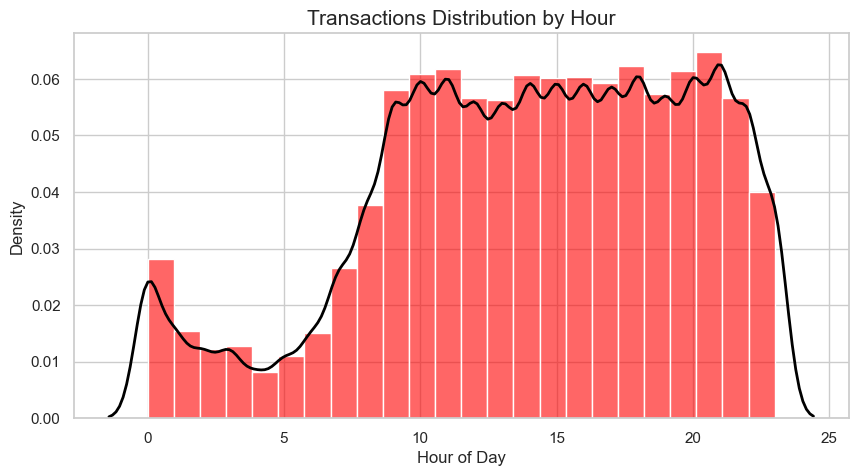

In [25]:
# Transactions by Hour
plt.figure(figsize=(10,5))

sns.histplot(df["time_hours"], bins=24, color="red", stat="density", alpha=0.6)
sns.kdeplot(df["time_hours"], color="black", linewidth=2)

plt.title("Transactions Distribution by Hour", fontsize=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

* **Higher transaction activity between approximately 9 AM and 9 PM.**
* **Transaction frequency is much lower between 12 AM and 6 AM.**
* The distribution of transactions across hours indicates that most transactions occur during daytime hours, particularly between late morning and evening. Transaction activity is significantly lower during early morning hours. 
* The KDE curve highlights peak transaction periods and provides a smooth representation of the temporal transaction pattern.
* Understanding normal transaction timing helps identify unusual patterns that may indicate fraudulent activity.

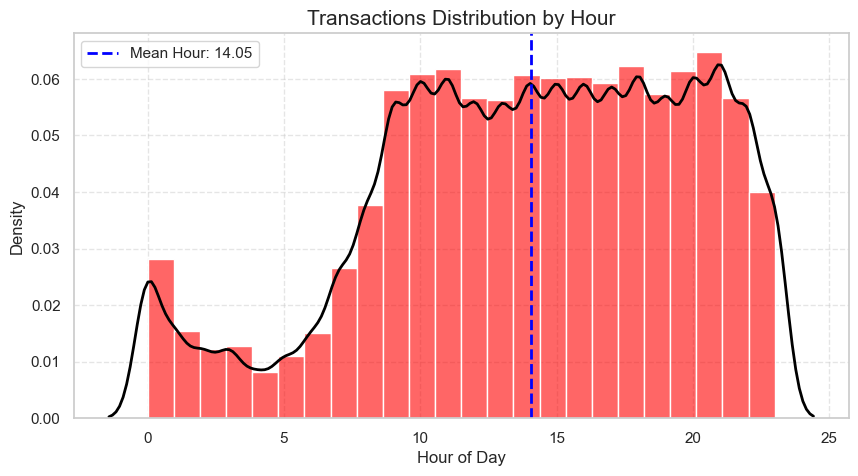

In [26]:
import numpy as np

plt.figure(figsize=(10,5))

sns.histplot(df["time_hours"], bins=24, color="red", stat="density", alpha=0.6)
sns.kdeplot(df["time_hours"], color="black", linewidth=2)

# Mean transaction hour
mean_hour = df["time_hours"].mean()
plt.axvline(mean_hour, color="blue", linestyle="--", linewidth=2, label=f"Mean Hour: {mean_hour:.2f}")

plt.title("Transactions Distribution by Hour", fontsize=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()

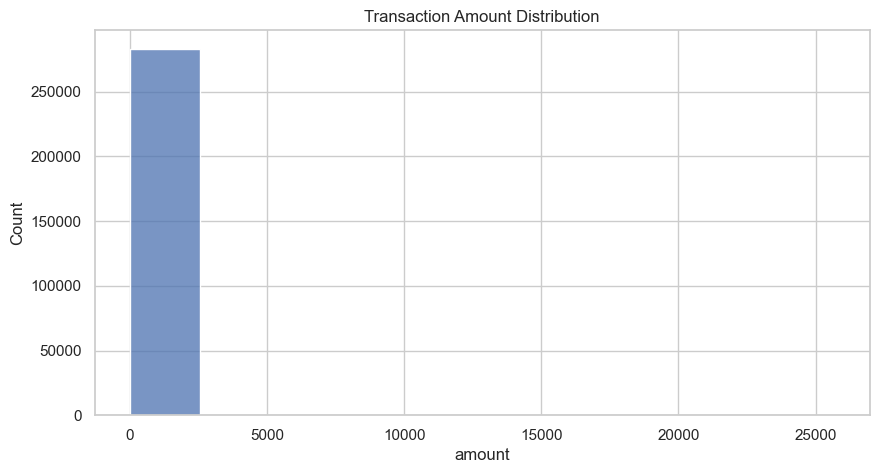

In [27]:
# Transaction Amount Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["amount"], bins=10)
plt.title("Transaction Amount Distribution")
plt.show()

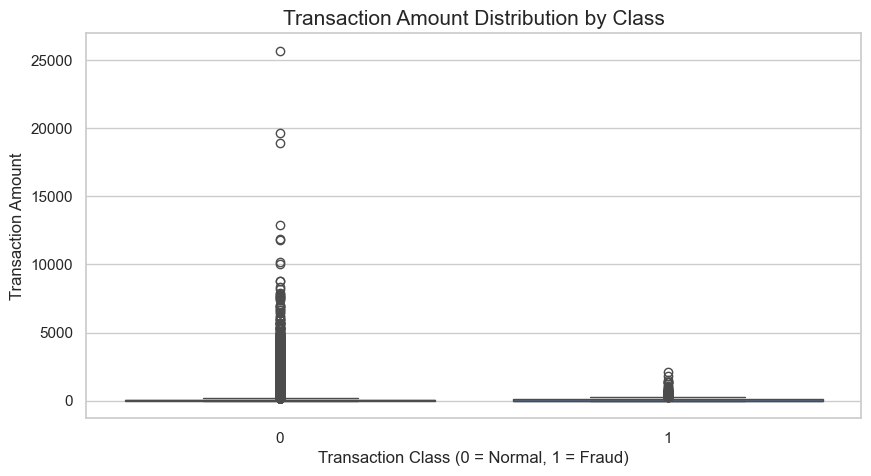

In [28]:
# Checking the outlier
plt.figure(figsize=(10,5))
sns.boxplot(x="class", y="amount", data=df)
plt.title("Transaction Amount Distribution by Class", fontsize=15)
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)", fontsize=12)
plt.ylabel("Transaction Amount", fontsize=12)

plt.show()

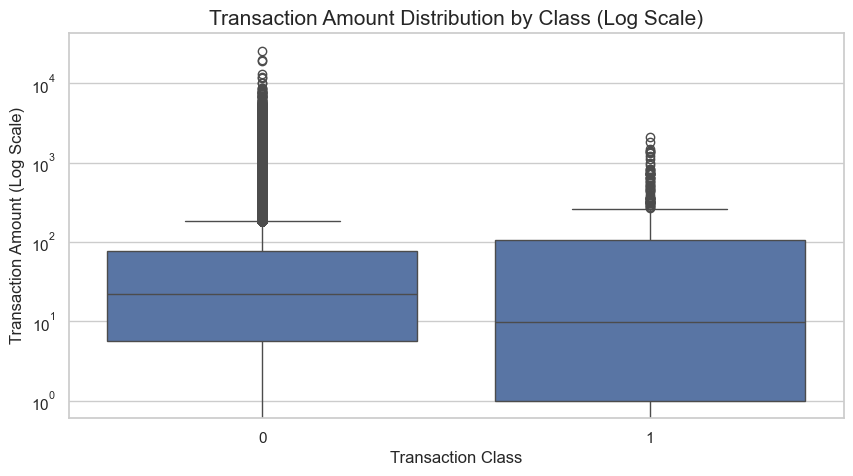

In [29]:
# Fraud vs Transaction Amount Outlier
plt.figure(figsize=(10,5))
sns.boxplot(x="class", y="amount", data=df)
plt.yscale("log")
plt.title("Transaction Amount Distribution by Class (Log Scale)", fontsize=15)
plt.xlabel("Transaction Class", fontsize=12)
plt.ylabel("Transaction Amount (Log Scale)", fontsize=12)
plt.show()

* The boxplot shows the distribution of transaction amounts for normal and fraudulent transactions. Fraudulent transactions exhibit several outliers, indicating unusual transaction values. 
* The distribution suggests that fraud may involve both unusually small and extremely large transaction amounts. Using a log scale helps visualize the highly skewed transaction amount distribution more clearly.

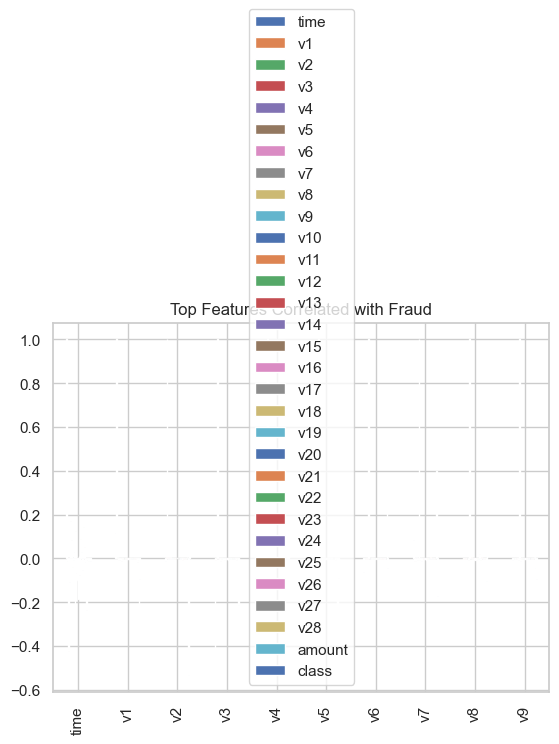

In [30]:
# Correlation with Class
corr.head(10).plot(kind="bar")

plt.title("Top Features Correlated with Fraud")

plt.show()

#### **Fraud vs Legitimate Feature Comparison**

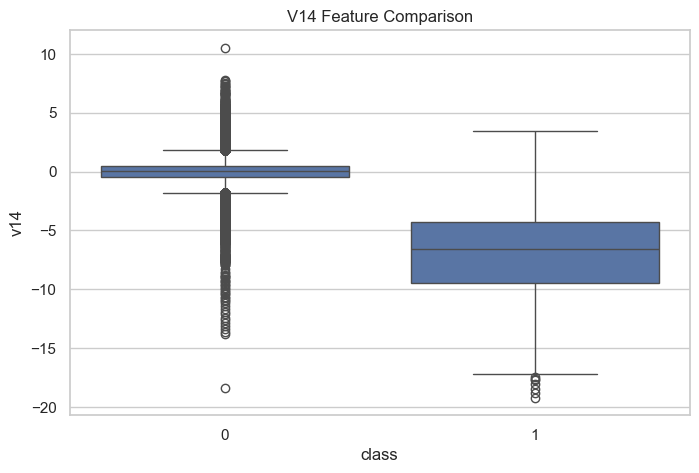

In [31]:
# V14 Fraud Comparison
plt.figure(figsize=(8,5))

sns.boxplot(x="class", y="v14", data=df)

plt.title("V14 Feature Comparison")

plt.show()

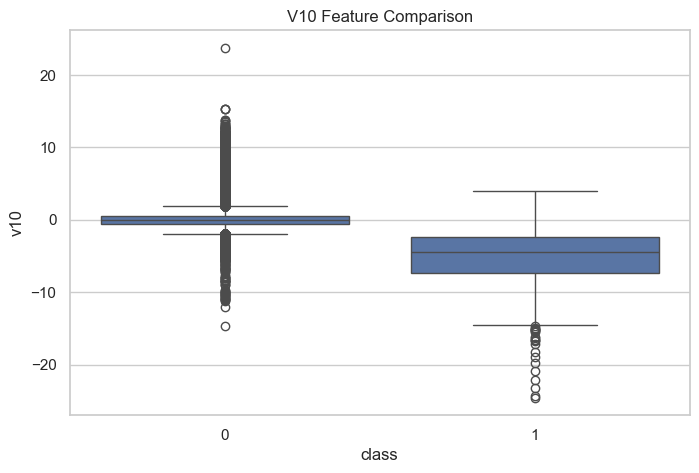

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="class", y="v10", data=df)

plt.title("V10 Feature Comparison")

plt.show()

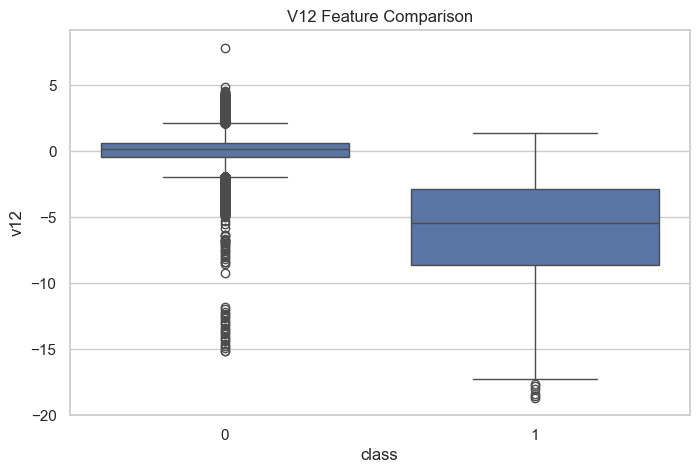

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x="class", y="v12", data=df)

plt.title("V12 Feature Comparison")

plt.show()

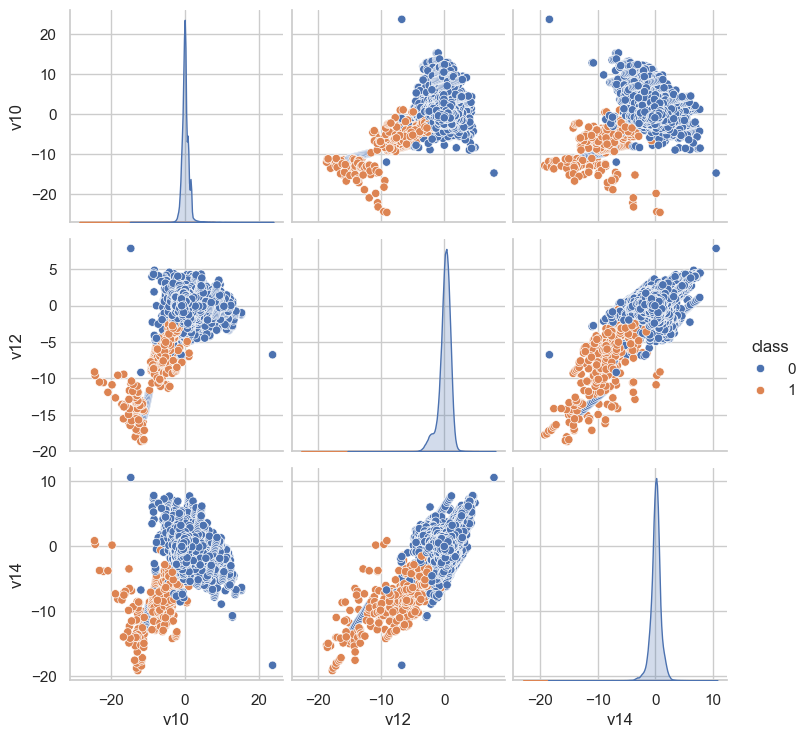

In [34]:
# Pairplot Feature Relationships
sns.pairplot(
    df[["v10","v12","v14","class"]],
    hue="class",
    diag_kind="kde"
)

plt.show()

* The pairplot visualization illustrates the relationships between important PCA-transformed features (V10, V12, and V14) and the transaction class. Fraudulent transactions form distinct clusters that differ from normal transactions, indicating that these features capture important patterns associated with fraudulent behavior. 
* The clear separation between fraud and non-fraud observations suggests that these variables can significantly contribute to machine learning models for fraud detection.

* To identify important features, I used correlation analysis and pairplot visualization to identify features that show clear separation between fraud and normal transactions. Features like V10, V12, and V14 showed strong separation patterns, indicating their importance in fraud detection models.

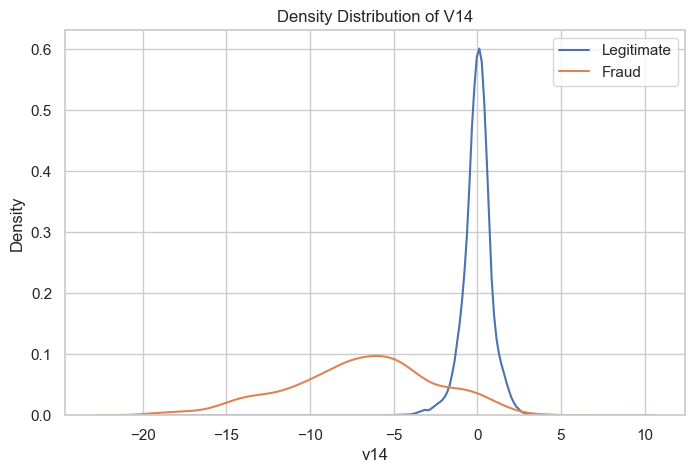

In [35]:
# Fraud Density plot (V14)
plt.figure(figsize=(8,5))
sns.kdeplot(df[df["class"]==0]["v14"], label="Legitimate")
sns.kdeplot(df[df["class"]==1]["v14"], label="Fraud")
plt.legend()
plt.title("Density Distribution of V14")
plt.show()

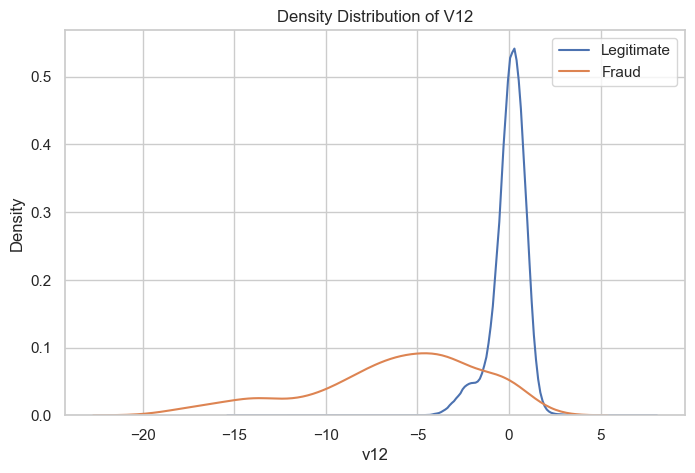

In [36]:
# Fraud Density plot (V12)
plt.figure(figsize=(8,5))
sns.kdeplot(df[df["class"]==0]["v12"], label="Legitimate")
sns.kdeplot(df[df["class"]==1]["v12"], label="Fraud")
plt.legend()
plt.title("Density Distribution of V12")
plt.show()

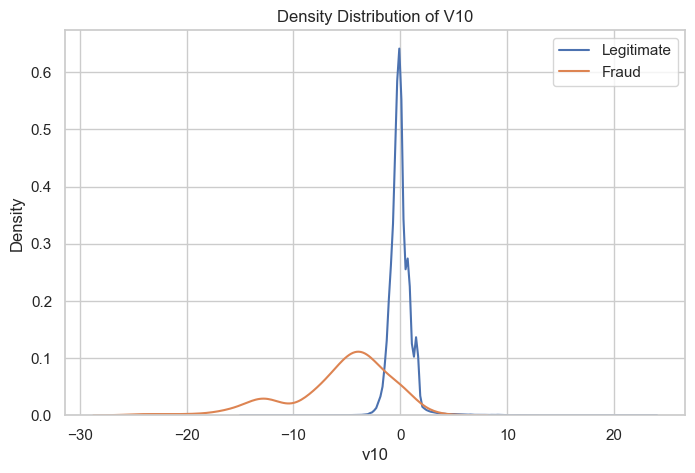

In [37]:
# # Fraud Density plot (V10)
plt.figure(figsize=(8,5))
sns.kdeplot(df[df["class"]==0]["v10"], label="Legitimate")
sns.kdeplot(df[df["class"]==1]["v10"], label="Fraud")
plt.legend()
plt.title("Density Distribution of V10")
plt.show()

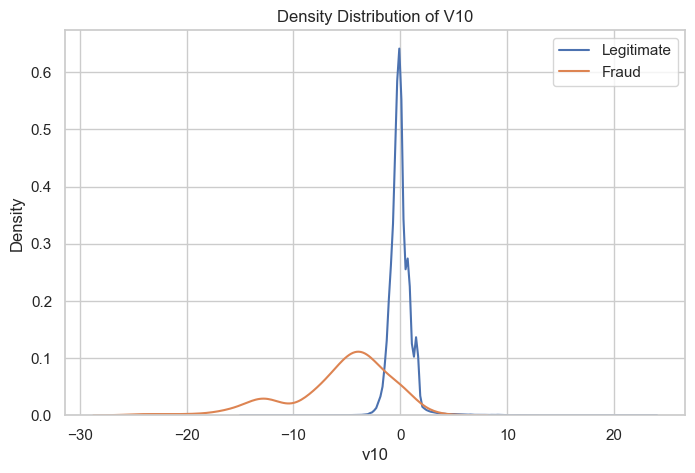

In [38]:
plt.figure(figsize=(8,5))
sns.kdeplot(df[df["class"]==0]["v10"], label="Legitimate")
sns.kdeplot(df[df["class"]==1]["v10"], label="Fraud")
plt.legend()
plt.title("Density Distribution of V10")
plt.show()

#### **Separate Plot for Each Feature**

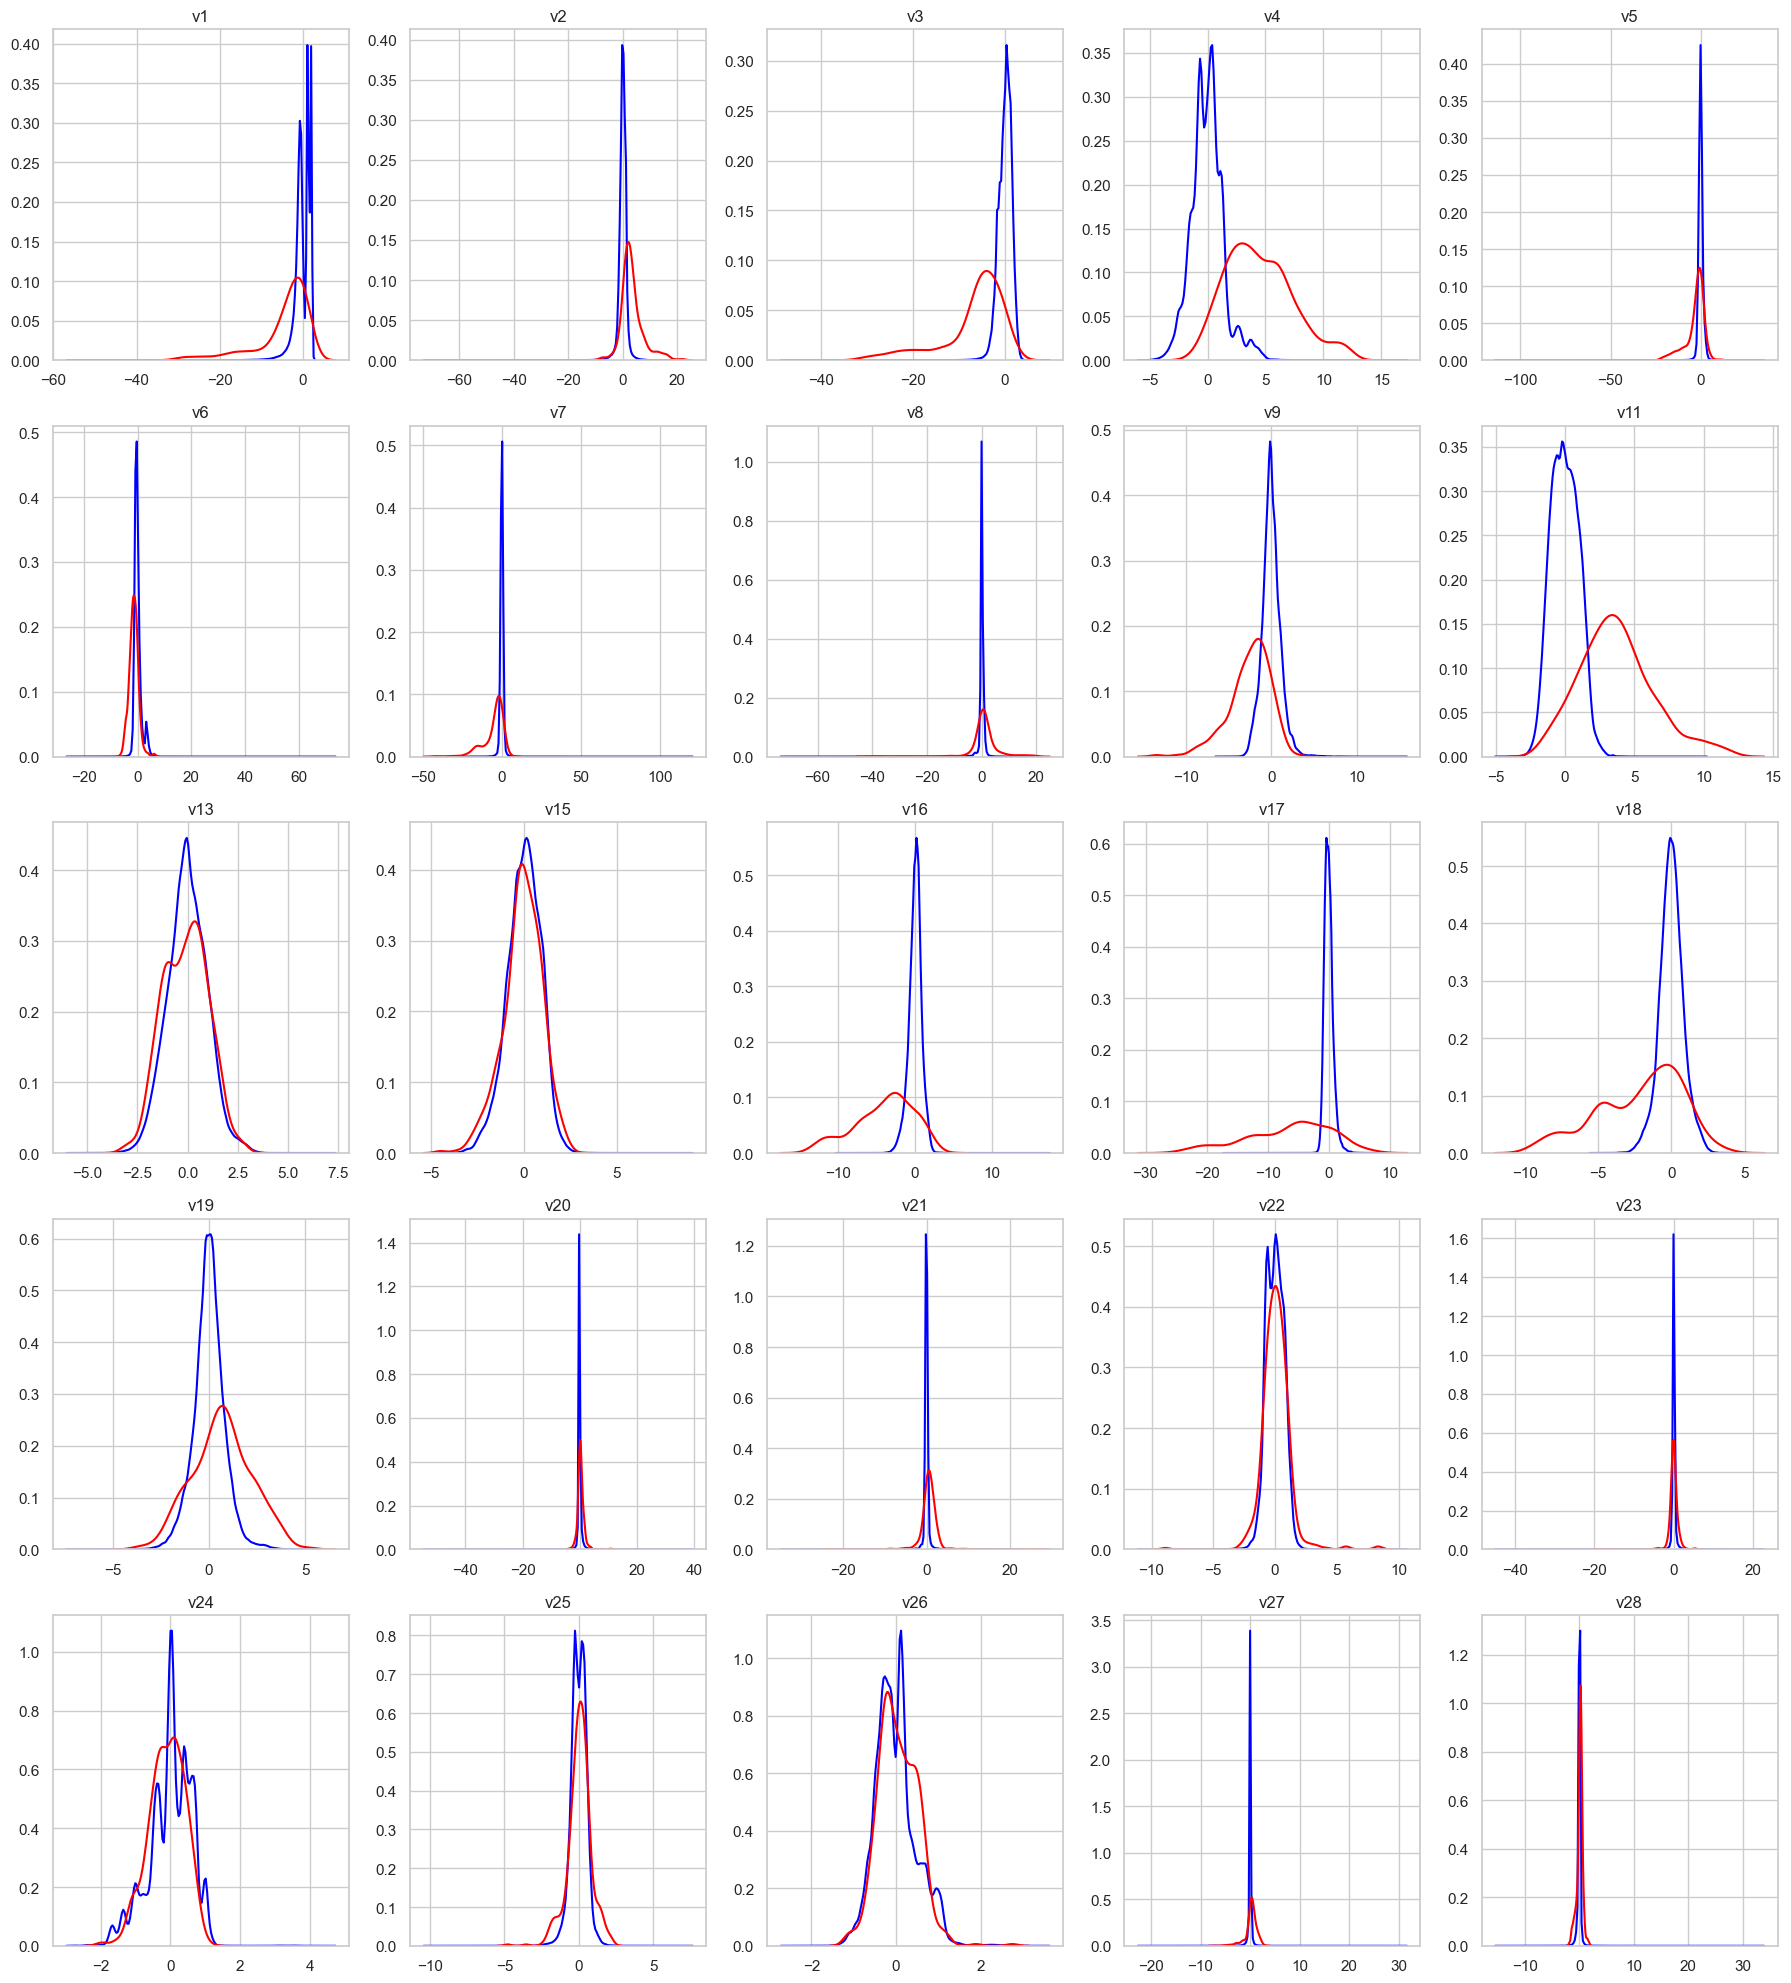

In [39]:

# All PCA features except V10, V12, V14
features = [f"v{i}" for i in range(1,29) if f"v{i}" not in ["v10","v12","v14"]]

plt.figure(figsize=(18,20))

for i, feature in enumerate(features,1):
    
    plt.subplot(5,5,i)
    sns.kdeplot(df[df["class"]==0][feature], label="Legitimate", color="blue")
    sns.kdeplot(df[df["class"]==1][feature], label="Fraud", color="red")
    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("")
    
plt.tight_layout()
plt.show()

* KDE distribution plots were used to compare feature distributions between legitimate and fraudulent transactions. Several PCA components exhibit clear differences between the two classes, indicating their importance for fraud detection. 
* Fraudulent transactions tend to have wider distributions and appear more frequently in extreme value ranges, reflecting abnormal transaction behavior. However, some features show overlapping distributions, suggesting they may have limited predictive power.

In [40]:
df

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v22,v23,v24,v25,v26,v27,v28,amount,class,time_hours
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23


# **Splitting dataset into Train and Test data**

In [41]:
# Splitting dataset into x and y
y = df['class']
x = df.drop(['class'], axis = 1)

In [42]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

In [43]:
x.head()

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,time_hours
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [44]:
# Splitting data using train_test_split

x_train, y_train, x_test, y_test = train_test_split(x, y, random_state = 100, test_size = 0.20)

In [45]:
# Checking the spread of data post split
print(np.sum(y))
print(np.sum(y_test))
print(np.sum(y_train))


473
113
v1            3.224639e+02
v2           -6.686713e+01
v3            2.845958e+02
v4           -1.411383e+02
v5            3.972676e+02
v6           -6.686330e+02
v7           -2.742545e+02
v8           -4.979002e+01
v9           -4.495059e+02
v10          -6.955269e+01
v11           9.332335e+01
v12          -2.258491e+02
v13          -2.198072e+02
v14          -2.487966e+02
v15           3.117687e+02
v16           1.274599e+02
v17          -4.011957e+02
v18           3.090675e+01
v19          -1.054670e+02
v20          -1.694248e+02
v21          -7.424067e+01
v22          -2.194261e+02
v23          -5.066810e+00
v24          -6.279051e+01
v25           3.078988e+01
v26           1.079155e+02
v27           9.653142e+01
v28           5.096651e+01
amount        4.938012e+06
time_hours    7.957400e+05
dtype: float64


In [46]:
#print(np.sum(x))
print(np.sum(x_test))
print(np.sum(x_train))

360
v1            1.356385e+03
v2           -1.106271e+03
v3            1.730881e+02
v4           -7.004803e+02
v5            1.212587e+02
v6            3.453306e+02
v7            7.851576e+02
v8           -1.926404e+02
v9           -3.377420e+00
v10          -3.392143e+02
v11          -3.607946e+01
v12           2.304529e+01
v13           3.910006e+02
v14           3.203856e+02
v15          -1.588844e+01
v16           2.022333e+02
v17           4.494748e+02
v18           3.989852e+02
v19           3.048850e+01
v20           2.225312e+02
v21          -3.090623e+01
v22           2.151624e+02
v23           6.129300e+01
v24           1.235666e+02
v25          -9.672411e+01
v26          -6.551515e+01
v27           4.036865e+02
v28           1.043202e+02
amount        2.016399e+07
time_hours    3.189375e+06
dtype: float64


In [47]:
# Accumulating all the column names under one variable
cols = list(x.columns.values)
cols

['v1',
 'v2',
 'v3',
 'v4',
 'v5',
 'v6',
 'v7',
 'v8',
 'v9',
 'v10',
 'v11',
 'v12',
 'v13',
 'v14',
 'v15',
 'v16',
 'v17',
 'v18',
 'v19',
 'v20',
 'v21',
 'v22',
 'v23',
 'v24',
 'v25',
 'v26',
 'v27',
 'v28',
 'amount',
 'time_hours']

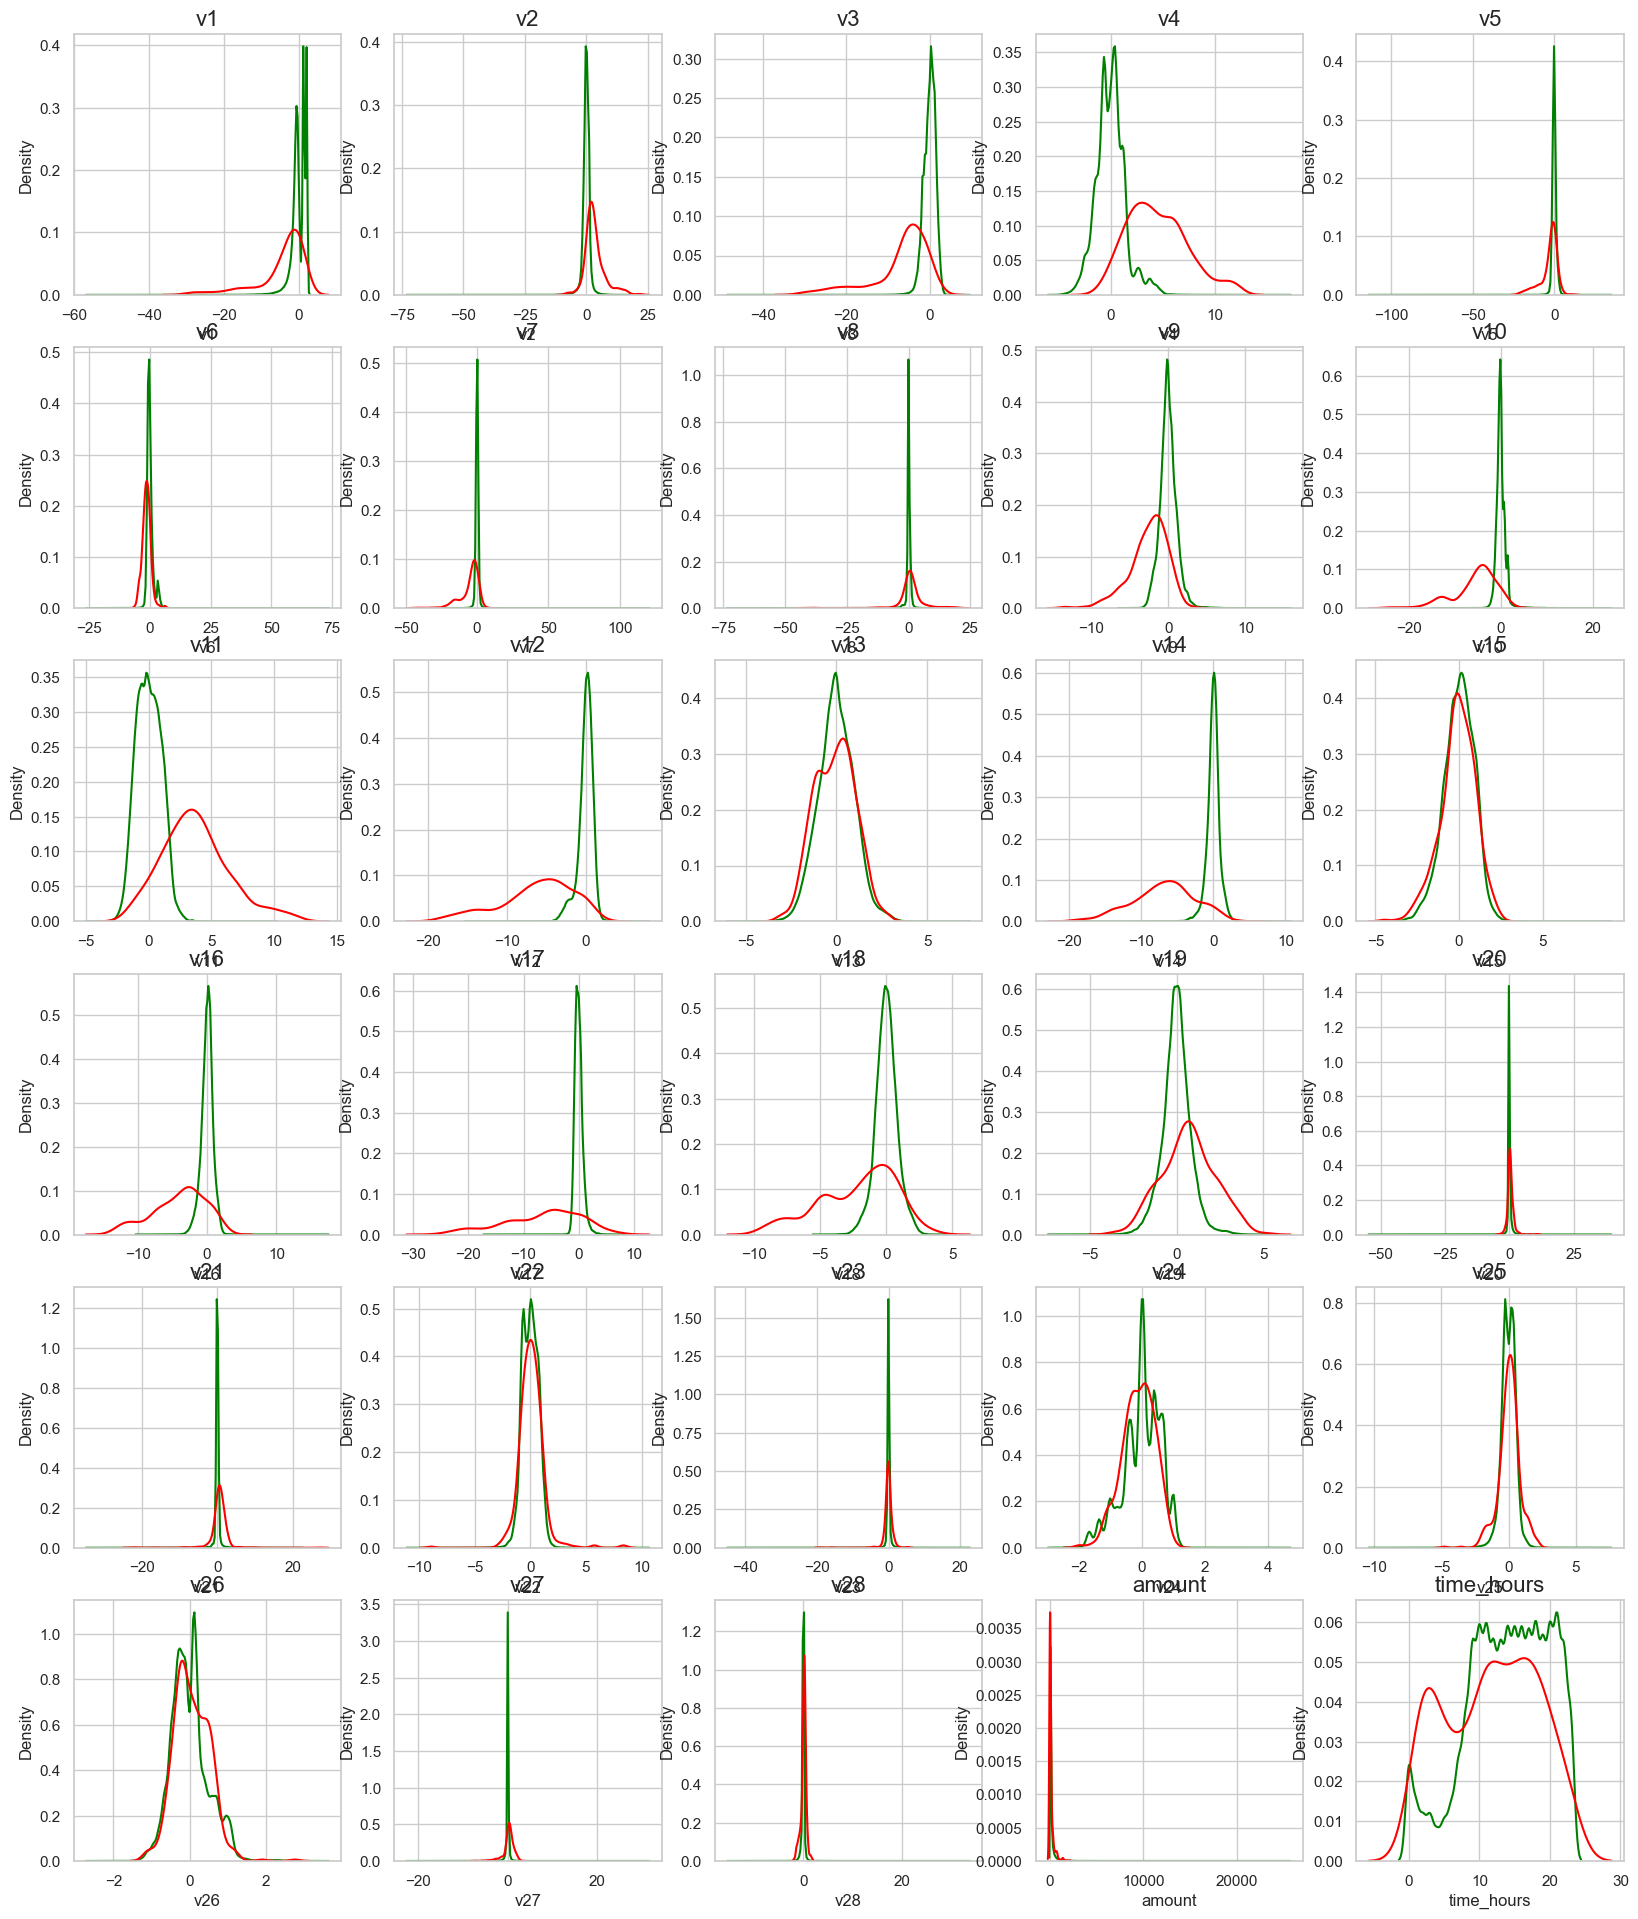

In [48]:
# Plot  the histogram of a variable from the dataset to see the skewness
normal_records = df['class'] == 0
fraud_records = df['class'] == 1

plt.figure(figsize = (20,40))
for n, col in enumerate(cols):
    plt.subplot(10, 5, n+1)
    sns.kdeplot(x[col][normal_records], color = 'green')
    sns.kdeplot(x[col][fraud_records], color = 'red')
    plt.title(col, fontsize = 16)
plt.show()

# **Model Building**

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [50]:
# Apply Logistic Regression Model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [51]:
# Apply Random Forest Model
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [52]:
# Predict on Logistic Regression and Random Forest
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [53]:
# Confusion matrix on predicted logistic Regression model
confusion_matrix(y_test, y_pred_lr)

array([[56650,     6],
       [   40,    50]], dtype=int64)

In [54]:
# Confusion matrix on predicted Random Forest model
confusion_matrix(y_test, y_pred_rf)

array([[56654,     2],
       [   25,    65]], dtype=int64)

In [55]:
# Classification report on logistic Regression model
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.56      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [56]:
# Classification report on Random Forest model
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.72      0.83        90

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [57]:
# ROC AUC score for Logistic Regression
roc_auc_score(y_test, y_pred_lr)

0.7777248266340331

In [58]:
# # ROC AUC score for Random Forest
roc_auc_score(y_test, y_pred_rf)

0.8610934607298629

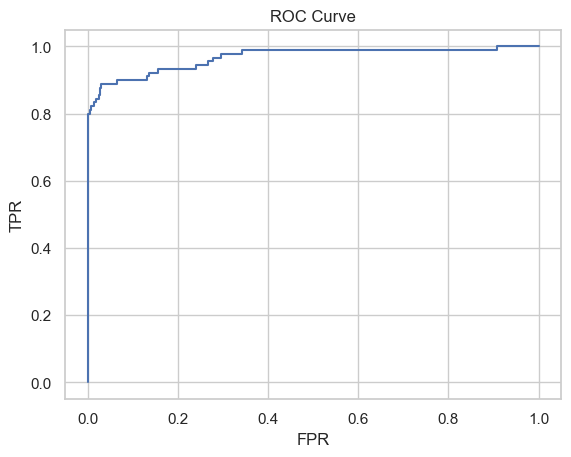

In [59]:
# ROC Curve for Logistic regression
y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

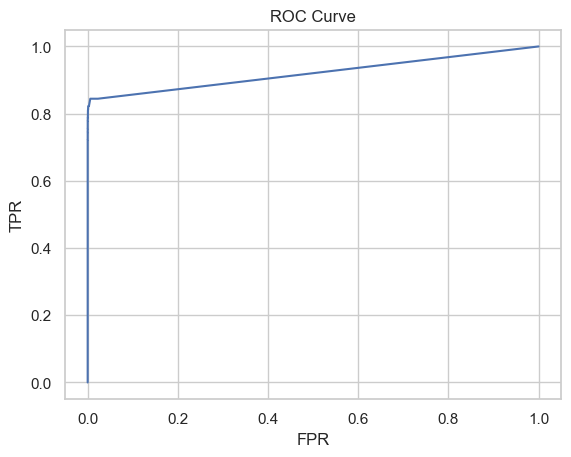

In [60]:
# ROC Curve for Random Forest
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

* The Random Forest model demonstrates strong classification performance with an AUC of ~0.95. It achieves a high precision of 93%, significantly reducing false positives, while maintaining a good recall of 80%. Compared to Logistic Regression, it provides a better balance for real-world fraud detection, where minimizing false alerts is critical.

In [61]:
# Apply XGBoost Prediction Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handle imbalance
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [62]:
# Apply Decision Tree Prediction Model

dt_model = DecisionTreeClassifier(
    max_depth=5,              # control overfitting
    min_samples_split=10,     # minimum samples to split
    min_samples_leaf=5,       # minimum samples in leaf
    random_state=42
)

In [63]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [64]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [65]:
# Confusion Matrix, ROC-AUC Score and Classification report for Decision Tree Classification Model

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))

Confusion Matrix:
 [[56651     5]
 [   24    66]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.93      0.73      0.82        90

    accuracy                           1.00     56746
   macro avg       0.96      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746


ROC-AUC Score: 0.8665019297750165


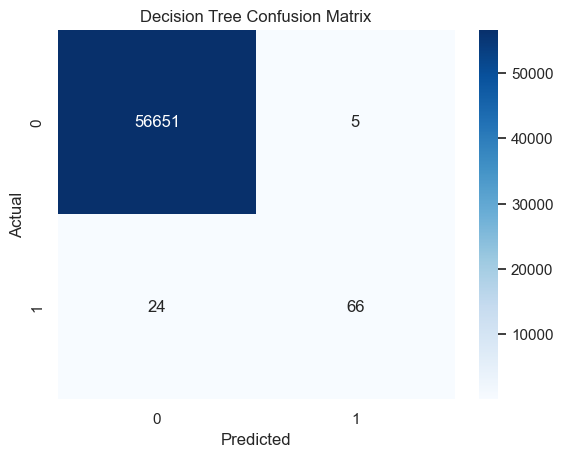

In [66]:
# Decision tree Confution matrix vusal
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

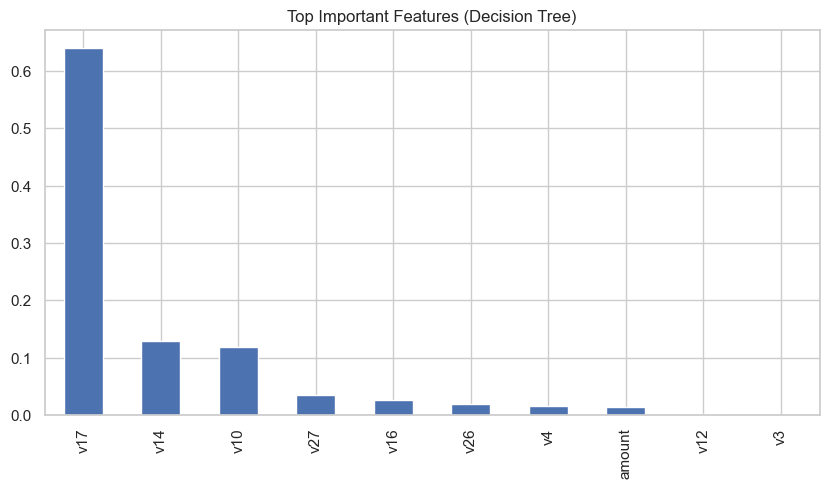

In [67]:

importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Important Features (Decision Tree)")
plt.show()

* The Decision Tree model was trained to classify fraudulent and legitimate transactions. The model captures non-linear relationships between features and identifies important variables contributing to fraud detection. Feature importance analysis highlights key predictors that influence the classification.

In [68]:
# Confusion Matrix, ROC-AUC Score and Classification report for XGBoost Model

from sklearn.metrics import classification_report, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification report:\n", classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Confusion Matrix:
 [[56649     7]
 [   22    68]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.91      0.76      0.82        90

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9746569942577427


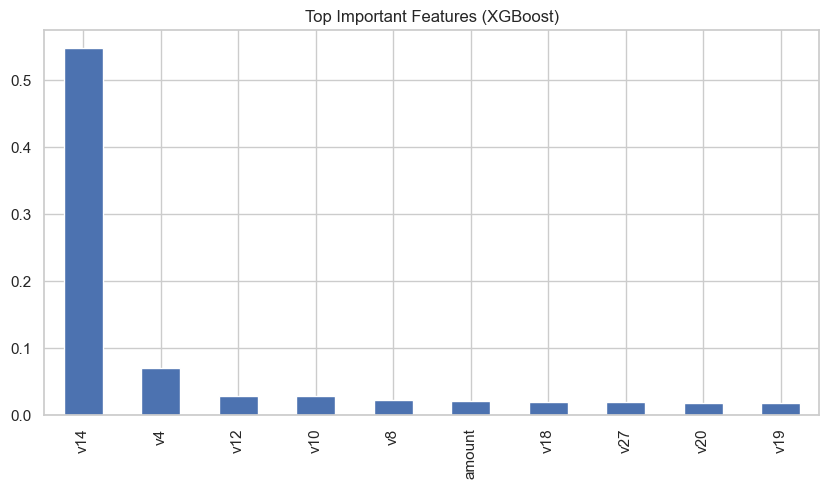

In [69]:
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Important Features (XGBoost)")
plt.show()

* The Decision Tree model relies heavily on a single feature (V17), indicating potential overfitting and limited generalization. In contrast, XGBoost distributes importance across multiple features such as V14, V4, and V10, capturing more complex patterns. This makes XGBoost more robust and better suited for real-world fraud detection.

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [71]:
import sys
print(sys.executable)

e:\INFYNTREK_DA\Transactional Fraud Detection\.venv\Scripts\python.exe


In [72]:
results = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "Decision Tree": dt_model
}

for name, model in models.items():
    results.append(evaluate_model(name, model, X_test, y_test))

results_df = pd.DataFrame(results)

# Sort by F1 Score (initial view)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.970149,0.722222,0.828025,0.920333
2,XGBoost,0.906667,0.755556,0.824242,0.974657
3,Decision Tree,0.929577,0.733333,0.819876,0.866502
0,Logistic Regression,0.892857,0.555556,0.684932,0.966876


In [73]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [74]:
print(pd.Series(y_train_smote).value_counts())

class
0    226597
1    226597
Name: count, dtype: int64


In [75]:
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [76]:
# Compare with difference models
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "Decision Tree": dt_model
}

In [77]:
# Create function to evalute metrics with other models
def evaluate_metrics(y_test, y_pred, y_prob):
    return {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [78]:
def find_best_threshold(y_test, y_prob):
    
    thresholds = np.arange(0.05, 0.8, 0.02)   # lower range = more fraud detection
    
    best_score = 0
    best_t = 0.3   # better starting point
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # HEAVY RECALL PRIORITY
        score = (0.7 * recall) + (0.2 * f1) + (0.1 * precision)
        
        if score > best_score:
            best_score = score
            best_t = t
    
    return best_t, best_score

In [80]:
results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    # Create pipeline (SMOTE inside CV → NO data leakage)
    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", clone(model))
    ])
    
    # Cross-validation AUC
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    # Train on full training set
    pipeline.fit(X_train, y_train)
    
    # Predict probabilities
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Find best threshold
    best_t, best_score = find_best_threshold(y_test, y_prob)
    
    # Final predictions using best threshold
    y_pred = (y_prob > best_t).astype(int)
    
    # Metrics
    metrics = evaluate_metrics(y_test, y_pred, y_prob)
    
    results.append({
        "Model": name,
        "Best Threshold": round(best_t, 2),
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1 Score": metrics["F1 Score"],
        "ROC-AUC": metrics["ROC-AUC"],
        "CV Mean AUC": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Final Score": best_score
    })

In [81]:
final_df = pd.DataFrame(results)
final_df = final_df.sort_values(by="Final Score", ascending=False)

final_df

,Model,Best Threshold,Precision,Recall,F1 Score,ROC-AUC,CV Mean AUC,CV Std,Final Score
1,Random Forest,0.41,0.901235,0.811111,0.853801,0.965399,0.970302,0.010815,0.828661
2,XGBoost,0.79,0.598425,0.844444,0.700461,0.963161,0.960824,0.019744,0.791046
0,Logistic Regression,0.05,0.005902,0.977778,0.011733,0.972264,0.974187,0.025430,0.687381
3,Decision Tree,0.05,0.009658,0.922222,0.019116,0.962406,0.943208,0.008416,0.650344


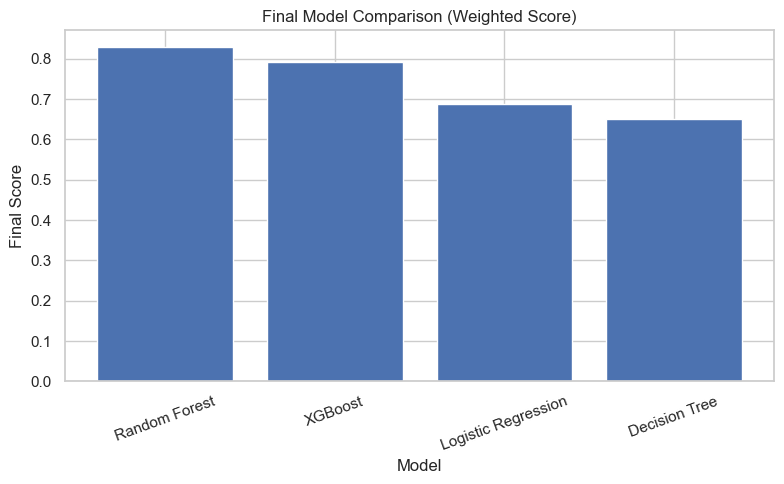

In [82]:
# Bar Chart: Final Score Comparison

plt.figure(figsize=(8,5))

plt.bar(final_df["Model"], final_df["Final Score"])

plt.title("Final Model Comparison (Weighted Score)")
plt.xlabel("Model")
plt.ylabel("Final Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

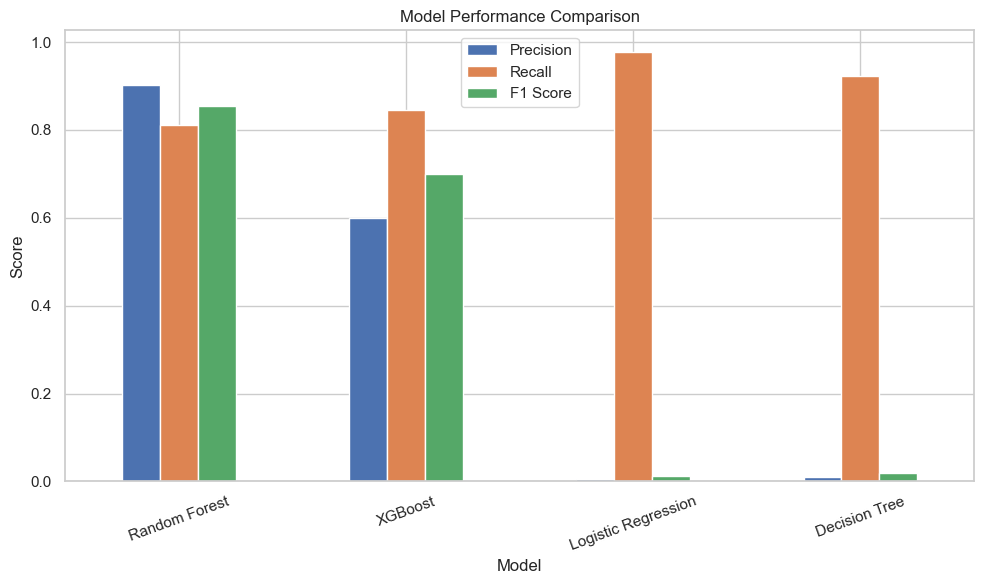

In [83]:
# Multi-Metric Comparison
metrics = ["Precision", "Recall", "F1 Score"]

final_df.set_index("Model")[metrics].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

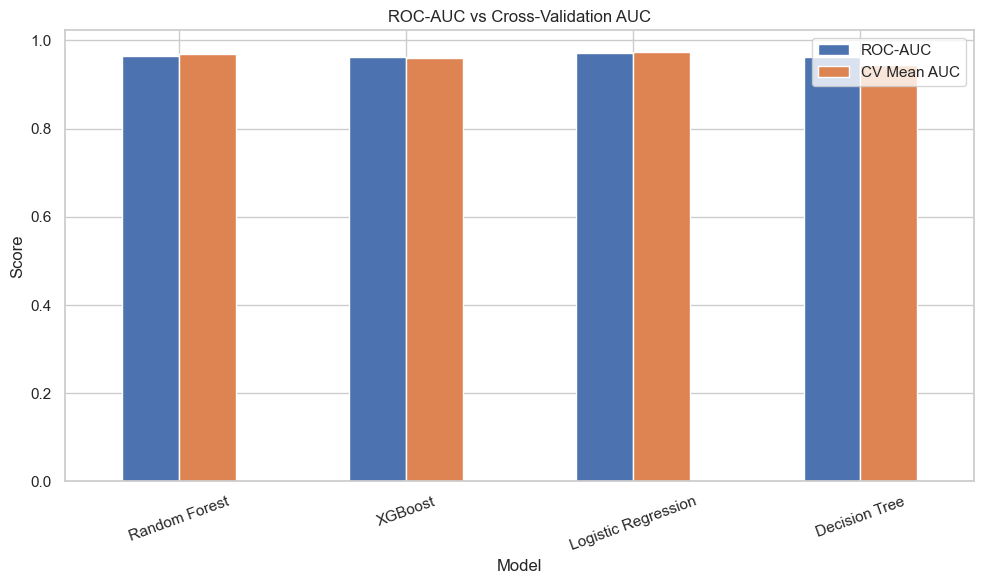

In [ ]:
# ROC-AUC vs CV Mean for Stability Checking

metrics = ["ROC-AUC", "CV Mean AUC"]

final_df.set_index("Model")[metrics].plot(kind="bar", figsize=(10,6))

plt.title("ROC-AUC vs Cross-Validation AUC")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

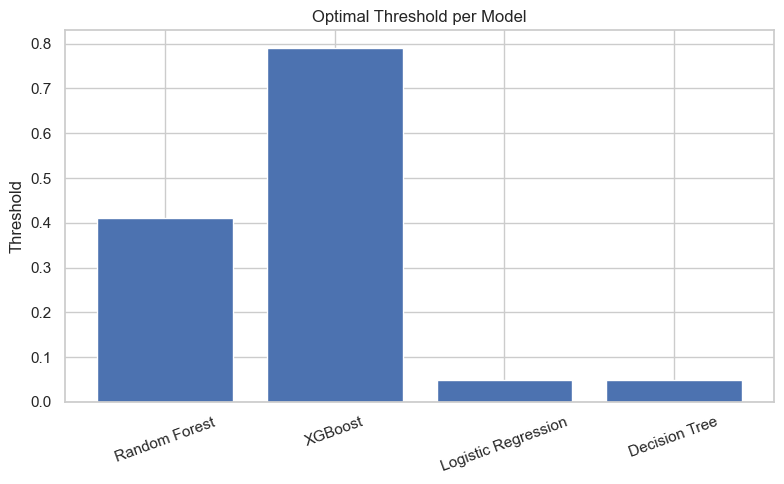

In [85]:
# Threshold Comparison

plt.figure(figsize=(8,5))

plt.bar(final_df["Model"], final_df["Best Threshold"])

plt.title("Optimal Threshold per Model")
plt.ylabel("Threshold")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

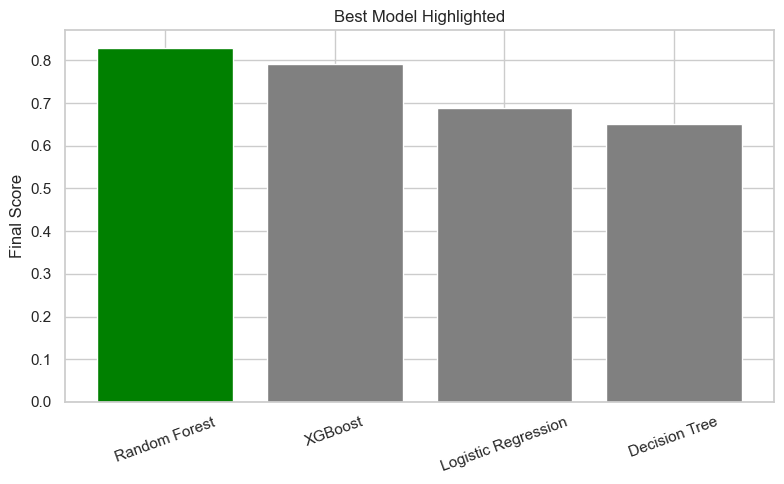

In [86]:
# Highlight Best Model

colors = ["green" if m == final_df.iloc[0]["Model"] else "gray" for m in final_df["Model"]]

plt.figure(figsize=(8,5))
plt.bar(final_df["Model"], final_df["Final Score"], color=colors)

plt.title("Best Model Highlighted")
plt.ylabel("Final Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [87]:
best_model = final_df.iloc[0]

print("Choose to BEST MODEL:", best_model["Model"])
print(best_model)

Choose to BEST MODEL: Random Forest
Model             Random Forest
Best Threshold             0.41
Precision              0.901235
Recall                 0.811111
F1 Score               0.853801
ROC-AUC                0.965399
CV Mean AUC            0.970302
CV Std                 0.010815
Final Score            0.828661
Name: 1, dtype: object


* Applying SMOTE improved recall across all models, enabling better detection of fraudulent transactions. However, it introduced a trade-off by reducing precision due to increased false positives. Among all models, Random Forest maintained the best balance between precision and recall both before and after SMOTE, making it the most reliable choice for deployment.

* SMOTE improved minority class learning but required threshold tuning to control false positives, highlighting the importance of combining resampling with decision threshold optimization.

*   Random Forest = BEST (consistent + balanced)
*    SMOTE = useful but needs threshold tuning
*   Logistic & DT = unstable with imbalance

In [88]:
# SAVE FINAL MODEL WITH SMOTE PIPELINE
import os
import joblib
from imblearn.pipeline import Pipeline

os.makedirs("models", exist_ok=True)

joblib.dump(pipeline, "../models/fraud_model.pkl")
joblib.dump(best_t, "../models/threshold.pkl")
joblib.dump(list(X_train.columns), "../models/features.pkl")
print("All  models are dumping")

All  models are dumping


In [ ]:
df

In [89]:
df.columns

Index(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11',
       'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21',
       'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class',
       'time_hours'],
      dtype='object')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   v1          283726 non-null  float64
 1   v2          283726 non-null  float64
 2   v3          283726 non-null  float64
 3   v4          283726 non-null  float64
 4   v5          283726 non-null  float64
 5   v6          283726 non-null  float64
 6   v7          283726 non-null  float64
 7   v8          283726 non-null  float64
 8   v9          283726 non-null  float64
 9   v10         283726 non-null  float64
 10  v11         283726 non-null  float64
 11  v12         283726 non-null  float64
 12  v13         283726 non-null  float64
 13  v14         283726 non-null  float64
 14  v15         283726 non-null  float64
 15  v16         283726 non-null  float64
 16  v17         283726 non-null  float64
 17  v18         283726 non-null  float64
 18  v19         283726 non-null  float64
 19  v20    

In [91]:
# Convert to timestamp
base_date = "2026-03-24"
df['time_hours'] = pd.to_datetime(base_date) + pd.to_timedelta(df['time_hours'], unit='h')

print(df[['time_hours']].tail())

                time_hours
284802 2026-03-24 23:00:00
284803 2026-03-24 23:00:00
284804 2026-03-24 23:00:00
284805 2026-03-24 23:00:00
284806 2026-03-24 23:00:00


In [92]:
df

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,...,v22,v23,v24,v25,v26,v27,v28,amount,class,time_hours
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,2026-03-24 00:00:00
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,2026-03-24 00:00:00
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,2026-03-24 00:00:00
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,2026-03-24 00:00:00
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,2026-03-24 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,2026-03-24 23:00:00
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,2026-03-24 23:00:00
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,2026-03-24 23:00:00
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,2026-03-24 23:00:00


In [93]:
df.to_csv("../data/clean_transactions.csv", index=False)

In [94]:
# =========================================
# CREATE POWER BI DATASET (FULL DATA)
# =========================================

# Predict on FULL dataset
y_prob = pipeline.predict_proba(x)[:, 1]
y_pred = (y_prob > best_t).astype(int)

# Create dataframe
powerbi_df = x.copy()

# Add original columns if needed
powerbi_df["Actual"] = y.values
powerbi_df["Predicted"] = y_pred
powerbi_df["Fraud_Probability"] = y_prob

# Risk segmentation (better bins)
powerbi_df["Risk_Level"] = pd.cut(
    powerbi_df["Fraud_Probability"],
    bins=[0, 0.3, 0.7, 0.9, 1],
    labels=["Low", "Medium", "High", "Very High"]
)

# Optional: Label column
powerbi_df["Fraud_Label"] = powerbi_df["Predicted"].map({
    0: "Normal",
    1: "Fraud"
})

# Save for Power BI
powerbi_df.to_csv("../data/powerbi_dashboard_data.csv", index=False)

print("✅ Power BI dataset ready (FULL DATA)")

✅ Power BI dataset ready (FULL DATA)
